In [ ]:
"""
=============================================================================
CS6140 Final Project — XLM-R 15 Language Pairs Full Fine-Tuning
=============================================================================
Full pipeline: LID → Tokenization → Training → Evaluation → σ_universality

Key settings:
  - 15 language pairs (all of SwitchLingua)
  - 8 train pairs / 7 zero-shot pairs
  - Full fine-tuning + bidirectional attention (no causal mask)
  - Inverse-frequency class weights, λ=1.0
  - Structural causality: h[t] → predict t+1
=============================================================================
"""
# Cell 0: Install dependencies
!pip install transformers torch sentencepiece datasets -q

In [ ]:
# Cell 1: Imports
import torch
from transformers import AutoTokenizer, pipeline
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict
import re
from tqdm import tqdm
from functools import lru_cache
import warnings
import unicodedata
warnings.filterwarnings('ignore')

print("✓ Libraries imported")

✓ Libraries imported


In [ ]:
# Cell 2: HuggingFace Login + Load Dataset
from huggingface_hub import login
login()

from datasets import load_dataset
dataset = load_dataset("Shelton1013/SwitchLingua_text")
print(f"Dataset size: {len(dataset['train'])}")

Arabic_eng.csv:   0%|          | 0.00/55.7M [00:00<?, ?B/s]

Can_Eng.csv:   0%|          | 0.00/694M [00:00<?, ?B/s]

Chinese_eng.csv:   0%|          | 0.00/56.7M [00:00<?, ?B/s]

French_eng.csv:   0%|          | 0.00/51.7M [00:00<?, ?B/s]

German_Eng.csv:   0%|          | 0.00/44.5M [00:00<?, ?B/s]

...

Russian_eng.csv:   0%|          | 0.00/55.4M [00:00<?, ?B/s]

Spanish_eng.csv:   0%|          | 0.00/50.8M [00:00<?, ?B/s]

Vietnamese_eng.csv:   0%|          | 0.00/57.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/234172 [00:00<?, ? examples/s]

Dataset size: 234172


In [ ]:
# Cell 3: Configuration — 15 pairs, 8 train / 7 zero-shot
# All 15 language pairs in SwitchLingua
ALL_LANGUAGE_PAIRS = [
    ("Cantonese", "English"),   # 119248 samples
    ("Arabic", "English"),      # 8548
    ("Philipines", "English"),  # 8537  # NOTE: Dataset uses "Philippines" (not "Philipines"). Corrected in Cell 7b.
    ("German", "French"),       # 8511
    ("Chinese", "English"),     # 8458
    ("Vietnamese", "English"),  # 8457
    ("Malay", "English"),       # 8386
    ("Japanese", "English"),    # 8385
    ("Hindi", "English"),       # 8381
    ("Korean", "English"),      # 8266
    ("Spanish", "English"),     # 8110
    ("French", "English"),      # 8070
    ("Russian", "English"),     # 8017
    ("Italian", "English"),     # 7979
    ("German", "English"),      # 6819
]

# ── Train pairs (8): max linguistic diversity ──────────────────────────────
# Chinese-EN:     Sino-Tibetan, logographic (CJK)
# Hindi-EN:       Indo-European / Indo-Aryan, Devanagari script
# Italian-EN:     Indo-European / Romance, Latin script
# German-EN:      Indo-European / Germanic, Latin script
# Arabic-EN:      Afro-Asiatic, Arabic script (RTL)
# Japanese-EN:    Japonic, mixed script (hiragana/katakana/kanji)
# Vietnamese-EN:  Austroasiatic, Latin script with tonal diacritics
# Spanish-EN:     Indo-European / Romance, Latin script (high CS frequency)

TRAIN_PAIRS = [
    ("Chinese", "English"),
    ("Hindi", "English"),
    ("Italian", "English"),
    ("German", "English"),
    ("Arabic", "English"),
    ("Japanese", "English"),
    ("Vietnamese", "English"),
    ("Spanish", "English"),
    ("Korean", "English"),
    ("Russian", "English"),
    ("French", "English"),
    ("Malay", "English"),
    ("Philipines", "English"),
    ("German", "French"),
    ("Cantonese", "English"),
]

# ── Zero-shot pairs (7): test generalization ──────────────────────────────
# Korean-EN:      unseen script (Hangul), unseen language family
# Russian-EN:     unseen script (Cyrillic), Indo-European / Slavic
# French-EN:      same family as Italian+Spanish (Romance) — tests within-family transfer
# Malay-EN:       unseen family (Austronesian), Latin script
# Filipino-EN:    unseen family (Austronesian), Latin script — double-checks Malay transfer
# German-French:  only non-English pair — hardest generalization test
# Cantonese-EN:   same script as Chinese-EN — tests Chinese→Cantonese transfer
#                 (not natively supported by XLM-R or mBERT, shares Unicode with Chinese)

ZEROSHOT_PAIRS = []  # no zero-shot
LAMBDA_DUR = 1.0     # set to 0.0 for single-task ablation


CONFIG = {
    'model_name': 'xlm-roberta-base',
    'lid_model': 'papluca/xlm-roberta-base-language-detection',
    'max_samples_per_pair': 6000,
    'device': 0 if torch.cuda.is_available() else -1,
}

print(f"Device: {'GPU' if CONFIG['device'] == 0 else 'CPU'}")
print(f"All language pairs: {len(ALL_LANGUAGE_PAIRS)}")
print(f"Train pairs: {len(TRAIN_PAIRS)}")
print(f"Zero-shot pairs: {len(ZEROSHOT_PAIRS)}")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f"✓ Tokenizer loaded: {CONFIG['model_name']}  |  vocab size: {tokenizer.vocab_size:,}")

Device: GPU
All language pairs: 15
Train pairs: 15
Zero-shot pairs: 0


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Tokenizer loaded: xlm-roberta-base  |  vocab size: 250,002


In [ ]:
# Cell 4: Production-Grade LID System
def is_language_neutral_content(text: str) -> bool:
    if not text or not text.strip():
        return True
    return not any(unicodedata.category(c).startswith('L') for c in text.strip())


class ProductionLID:
    def __init__(self, model_name: str = "papluca/xlm-roberta-base-language-detection"):
        print("Loading Transformer-based LID model...")
        self.device = 0 if torch.cuda.is_available() else -1
        self.lid_model = pipeline(
            "text-classification",
            model=model_name,
            device=self.device,
            batch_size=32,
        )

        self.lang_map = {
            'en': 'English',  'zh': 'Chinese', 'ja': 'Japanese',
            'ar': 'Arabic',   'hi': 'Hindi',   'vi': 'Vietnamese',
            'ru': 'Russian',  'fr': 'French',  'de': 'German',
            'es': 'Spanish',  'it': 'Italian', 'ko': 'Korean',
            'ms': 'Malay',    'tl': 'Filipino',
        }

        self.unicode_ranges = {
            'Japanese': [(0x3040, 0x309F), (0x30A0, 0x30FF)],
            'Korean':   [(0xAC00, 0xD7AF)],
            'Arabic':   [(0x0600, 0x06FF)],
            'Hindi':    [(0x0900, 0x097F)],
            'Russian':  [(0x0400, 0x04FF)],
            'Chinese':  [(0x4E00, 0x9FFF), (0x3400, 0x4DBF)],
        }

        self.lexicons = {
            'Vietnamese': frozenset([
                'có', 'là', 'không', 'và', 'của', 'cho', 'trong', 'với', 'được', 'này',
                'các', 'một', 'những', 'khi', 'nhưng', 'hay', 'để', 'từ', 'đã', 'cũng',
                'phải', 'sẽ', 'nếu', 'vì', 'hoặc', 'đến', 'ra', 'về', 'năm', 'người',
            ]),
            'Cantonese': frozenset([
                '嘅', '咗', '唔', '係', '喺', '咁', '哋', '嚟', '噉', '嘢', '啲', '咩',
                '冇', '佢', '乜', '嗰', '吖', '嘞', '噃', '啩', '咯', '㗎',
            ]),
            'German': frozenset([
                'ich', 'nicht', 'ist', 'das', 'die', 'der', 'und', 'ein', 'zu', 'mit',
                'sich', 'auf', 'auch', 'dass', 'aber', 'noch', 'wird', 'beim', 'vom',
                'haben', 'sein', 'war', 'sind', 'wurde', 'wenn', 'durch', 'nach', 'oder',
            ]),
            'French': frozenset([
                'je', 'ne', 'pas', 'est', 'les', 'des', 'une', 'que', 'qui', 'dans',
                'avec', 'sur', 'pour', 'par', 'mais', 'ont', 'être', 'très', 'bien',
                'nous', 'vous', 'ils', 'elle', 'tout', 'plus', 'cette', 'comme', 'aux',
            ]),
            'Malay': frozenset([
                'dan', 'yang', 'ini', 'itu', 'di', 'dengan', 'untuk', 'tidak', 'ada',
                'dari', 'dalam', 'akan', 'pada', 'juga', 'saya', 'sudah', 'bisa',
                'mereka', 'seperti', 'tetapi', 'atau', 'hanya', 'oleh', 'karena',
            ]),
            'Filipino': frozenset([
                'ang', 'mga', 'sa', 'na', 'ng', 'ko', 'ka', 'niya', 'siya', 'ito',
                'ako', 'mo', 'namin', 'nila', 'pero', 'kasi', 'talaga', 'lang',
                'din', 'dito', 'yung', 'parang', 'dapat', 'pwede', 'gusto',
            ]),
            'Korean': frozenset([
                '이', '그', '저', '것', '수', '등', '들', '및', '을', '를',
                '에', '의', '가', '으로', '하다', '있다', '되다', '없다',
            ]),
            'Spanish': frozenset([
                'el', 'la', 'los', 'las', 'un', 'una', 'que', 'en', 'es', 'por',
                'con', 'para', 'como', 'pero', 'más', 'este', 'ya', 'todo', 'esta',
                'ser', 'también', 'fue', 'había', 'muy', 'puede', 'todos', 'así',
                'nos', 'cuando', 'algo', 'entre', 'sin', 'sobre', 'tiene', 'donde',
            ]),
        }

        self.ngram_features = {
            'Vietnamese': frozenset('àáâãèéêìíòóôõùúýăđơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ'),
            'German':     frozenset('äöüßÄÖÜ'),
            'French':     frozenset('çœæÇŒÆ'),
            'Spanish':    frozenset('ñ¿¡Ñ'),
        }

        self._word_cache: dict[str, str] = {}
        print(f"✓ LID model loaded on {'GPU' if self.device >= 0 else 'CPU'}")

    def _unicode_check(self, text: str) -> str | None:
        for ch in text:
            cp = ord(ch)
            for lang, ranges in self.unicode_ranges.items():
                for lo, hi in ranges:
                    if lo <= cp <= hi:
                        return lang
        return None

    def _ngram_check(self, text: str, lang1: str, lang2: str) -> str | None:
        for lang, char_set in self.ngram_features.items():
            if lang not in (lang1, lang2):
                continue
            if any(c in char_set for c in text):
                return lang
        return None

    def _transformer_detect_single(self, text: str, lang1: str, lang2: str) -> str:
        try:
            results = self.lid_model(text, top_k=3)
            for r in results:
                label = r['label']
                detected = self.lang_map.get(label)
                if label == 'zh':
                    detected = 'Cantonese' if 'Cantonese' in (lang1, lang2) else 'Chinese'
                if detected in (lang1, lang2):
                    return detected
        except Exception:
            pass
        return lang1

    def _batch_transformer_detect(self, texts: list[str],
                                   lang1: str, lang2: str) -> list[str]:
        if not texts:
            return []
        unique = list(dict.fromkeys(texts))
        result_map: dict[str, str] = {}
        try:
            batch_results = self.lid_model(unique, top_k=3, batch_size=32)
            for word, top3 in zip(unique, batch_results):
                resolved = lang1
                for r in top3:
                    label = r['label']
                    detected = self.lang_map.get(label)
                    if label == 'zh':
                        detected = 'Cantonese' if 'Cantonese' in (lang1, lang2) else 'Chinese'
                    if detected in (lang1, lang2):
                        resolved = detected
                        break
                result_map[word] = resolved
        except Exception:
            result_map = {w: lang1 for w in unique}
        return [result_map[t] for t in texts]

    def detect_language(self, text: str, lang1: str, lang2: str) -> str:
        clean = re.sub(r'[^\w\s]', '', text).strip()
        if not clean or is_language_neutral_content(clean):
            return 'neutral'
        hit = self._unicode_check(clean)
        if hit and hit in (lang1, lang2):
            return hit
        word_lower = clean.lower().split()[0]
        for lang, lexicon in self.lexicons.items():
            if lang not in (lang1, lang2):
                continue
            if word_lower in lexicon or any(c in lexicon for c in clean):
                return lang
        hit = self._ngram_check(clean, lang1, lang2)
        if hit:
            return hit
        cached = self._word_cache.get(clean)
        if cached is not None:
            return cached
        result = self._transformer_detect_single(clean, lang1, lang2)
        self._cache_set(clean, result)
        return result

    def word_level_lid(self, text: str, lang1: str, lang2: str
                       ) -> Tuple[List[str], List[str]]:
        words = text.split()
        lids: list[str | None] = []
        l4_positions: list[int] = []
        l4_texts: list[str] = []

        for i, word in enumerate(words):
            clean = re.sub(r'[^\w]', '', word)
            if not clean or is_language_neutral_content(clean):
                lids.append('neutral')
                continue
            hit = self._unicode_check(clean)
            if hit and hit in (lang1, lang2):
                lids.append(hit)
                continue
            hit_lang = None
            word_lower = clean.lower()
            for lang, lexicon in self.lexicons.items():
                if lang not in (lang1, lang2):
                    continue
                if word_lower in lexicon or any(c in lexicon for c in clean):
                    hit_lang = lang
                    break
            if hit_lang:
                lids.append(hit_lang)
                continue
            hit = self._ngram_check(clean, lang1, lang2)
            if hit:
                lids.append(hit)
                continue
            cached = self._word_cache.get(clean)
            if cached is not None:
                lids.append(cached)
                continue
            lids.append(None)
            l4_positions.append(i)
            l4_texts.append(clean)

        if l4_texts:
            detected = self._batch_transformer_detect(l4_texts, lang1, lang2)
            for pos, lang, clean in zip(l4_positions, detected, l4_texts):
                lids[pos] = lang
                self._cache_set(clean, lang)

        lids = [l if l is not None else lang1 for l in lids]
        return words, lids

    def _cache_set(self, text: str, lang: str) -> None:
        if len(self._word_cache) >= 100_000:
            self._word_cache.clear()
        self._word_cache[text] = lang


print("Initializing Production LID System...")
production_lid = ProductionLID()
print("✓ LID System Ready\n")

Initializing Production LID System...
Loading Transformer-based LID model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: papluca/xlm-roberta-base-language-detection
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ LID model loaded on GPU
✓ LID System Ready



In [ ]:
# Cell 5: Subword alignment + Label generation
def align_subwords_to_words(words: List[str],
                             word_lids: List[str]) -> Tuple[List[str], List[str]]:
    assert len(words) == len(word_lids), (
        f"Length mismatch: {len(words)} words vs {len(word_lids)} lids"
    )
    tokens, token_lids = [], []
    for word, lid in zip(words, word_lids):
        word_tokens = tokenizer.tokenize(word)
        if not word_tokens:
            continue
        for token in word_tokens:
            clean_token = token.replace('▁', '').strip()
            if not clean_token or is_language_neutral_content(clean_token):
                tokens.append(token)
                token_lids.append('neutral')
            else:
                tokens.append(token)
                token_lids.append(lid)
    return tokens, token_lids


def generate_labels(token_lids: List[str]) -> Tuple[List[int], List[int]]:
    n = len(token_lids)
    if n < 2:
        return [], []

    next_nn: List[int | None] = [None] * n
    last_nn = None
    for i in range(n - 1, -1, -1):
        if token_lids[i] != 'neutral':
            last_nn = i
        next_nn[i] = last_nn

    y_switch   = []
    y_duration = []

    for t in range(n - 1):
        current_lid = token_lids[t]
        if current_lid == 'neutral':
            y_switch.append(0)
            y_duration.append(-1)
            continue

        next_pos = next_nn[t + 1] if t + 1 < n else None
        if next_pos is None:
            y_switch.append(0)
            y_duration.append(-1)
            continue

        next_lid  = token_lids[next_pos]
        is_switch = current_lid != next_lid
        y_switch.append(1 if is_switch else 0)

        if is_switch:
            burst_len = 1
            for i in range(next_pos + 1, n):
                if token_lids[i] == 'neutral':
                    continue
                if token_lids[i] == next_lid:
                    burst_len += 1
                else:
                    break
            if burst_len <= 2:
                y_duration.append(0)
            elif burst_len <= 6:
                y_duration.append(1)
            else:
                y_duration.append(2)
        else:
            y_duration.append(-1)

    return y_switch, y_duration

In [ ]:
# Cell 6: Sample processing + Language-pair analysis (unchanged)
def process_sample(sample: dict, lang1: str, lang2: str) -> dict | None:
    raw = sample.get('data_generation_result', '')
    if isinstance(raw, list):
        text = ' '.join(str(s) for s in raw if s)
    else:
        text = raw if isinstance(raw, str) else ''
    if not text or not text.strip():
        return None
    try:
        words, word_lids = production_lid.word_level_lid(text, lang1, lang2)
        tokens, token_lids = align_subwords_to_words(words, word_lids)
        if len(tokens) < 2:
            return None
        y_switch, y_duration = generate_labels(token_lids)
        return {
            'text':       text,
            'tokens':     tokens,
            'token_lids': token_lids,
            'y_switch':   y_switch,
            'y_duration': y_duration,
            'cs_type':    sample.get('cs_type',     'unknown'),
            'cs_function':sample.get('cs_function', 'unknown'),
        }
    except Exception as e:
        print(f"[process_sample] {lang1}-{lang2} | error: {type(e).__name__}: {e}")
        return None


def analyze_language_pair(dataset_split, lang1: str, lang2: str,
                           max_samples: int = 6000) -> dict | None:
    print(f"\n{'='*70}")
    print(f"Processing: {lang1} - {lang2}")
    print(f"{'='*70}")

    filtered_data = dataset_split.filter(
        lambda x: (x.get('first_language') == lang1 and x.get('second_language') == lang2) or
                  (x.get('first_language') == lang2 and x.get('second_language') == lang1)
    )

    print(f"Found {len(filtered_data)} samples")
    if len(filtered_data) == 0:
        print("No samples found, skipping...")
        return None

    sample_size   = min(len(filtered_data), max_samples)
    filtered_data = filtered_data.select(range(sample_size))

    stats = {
        'lang_pair':              f"{lang1}-{lang2}",
        'total_samples':          0,
        'total_tokens':           0,
        'total_switches':         0,
        'duration_distribution':  Counter(),
        'cs_type_distribution':   Counter(),
        'switch_rate_per_sample': [],
        'processed_samples':      [],
    }

    print(f"Processing {sample_size} samples...")
    for idx in tqdm(range(sample_size), desc=f"  {lang1}-{lang2}"):
        result = process_sample(filtered_data[idx], lang1, lang2)
        if result is None:
            continue

        stats['total_samples']  += 1
        stats['total_tokens']   += len(result['tokens'])
        stats['total_switches'] += sum(result['y_switch'])

        for dur in result['y_duration']:
            if dur != -1:
                stats['duration_distribution'][dur] += 1

        stats['cs_type_distribution'][result['cs_type']] += 1

        if result['tokens']:
            stats['switch_rate_per_sample'].append(
                sum(result['y_switch']) / len(result['tokens'])
            )

        stats['processed_samples'].append(result)

    failed = sample_size - stats['total_samples']
    print(f"✓ Processed: {stats['total_samples']:,}  |  Failed: {failed}")

    if stats['total_tokens'] > 0:
        sr = stats['total_switches'] / stats['total_tokens']
        print(f"  Tokens: {stats['total_tokens']:,}  |  Switches: {stats['total_switches']:,}  |  Rate: {sr:.2%}")

    dur_total = sum(stats['duration_distribution'].values())
    if dur_total:
        labels = ['Small (1-2)', 'Medium (3-6)', 'Large (7+)']
        parts = []
        for k in sorted(stats['duration_distribution']):
            c = stats['duration_distribution'][k]
            parts.append(f"{labels[k]}={c}")
        print(f"  Duration dist: {', '.join(parts)}")

    return stats

In [ ]:
# Cell 7: Batch processing ALL 15 language pairs
print("\n" + "="*70)
print("BATCH PROCESSING ALL 15 LANGUAGE PAIRS (XLM-R tokenizer)")
print("="*70)

all_stats = {}

for lang1, lang2 in ALL_LANGUAGE_PAIRS:
    try:
        stats = analyze_language_pair(
            dataset['train'], lang1, lang2,
            max_samples=CONFIG['max_samples_per_pair']
        )
        if stats is not None:
            pair_key = f"{lang1}-{lang2}"
            all_stats[pair_key] = stats
    except Exception as e:
        print(f"  Error processing {lang1}-{lang2}: {e}")
        continue

print(f"\n{'='*70}")
print(f"✓ COMPLETED! Processed {len(all_stats)} / {len(ALL_LANGUAGE_PAIRS)} language pairs")
print(f"Total samples: {sum(s['total_samples'] for s in all_stats.values()):,}")
print(f"Total tokens:  {sum(s['total_tokens'] for s in all_stats.values()):,}")
print(f"{'='*70}\n")


BATCH PROCESSING ALL 15 LANGUAGE PAIRS (XLM-R tokenizer)

Processing: Cantonese - English


Filter:   0%|          | 0/234172 [00:00<?, ? examples/s]

Found 119248 samples
Processing 6000 samples...


  Cantonese-English: 100%|██████████| 6000/6000 [01:06<00:00, 90.29it/s] 

✓ Processed: 6,000  |  Failed: 0
  Tokens: 720,092  |  Switches: 39,073  |  Rate: 5.43%
  Duration dist: Small (1-2)=12609, Medium (3-6)=9694, Large (7+)=16770

Processing: Arabic - English


...

✓ Processed: 6,000  |  Failed: 0
  Tokens: 512,413  |  Switches: 125,200  |  Rate: 24.43%
  Duration dist: Small (1-2)=79430, Medium (3-6)=30380, Large (7+)=15390

Processing: German - English


Filter:   0%|          | 0/234172 [00:00<?, ? examples/s]

Found 6819 samples
Processing 6000 samples...


  German-English: 100%|██████████| 6000/6000 [01:11<00:00, 84.39it/s] 

✓ Processed: 6,000  |  Failed: 0
  Tokens: 474,476  |  Switches: 82,462  |  Rate: 17.38%
  Duration dist: Small (1-2)=44255, Medium (3-6)=20397, Large (7+)=17810

✓ COMPLETED! Processed 14 / 15 language pairs
Total samples: 84,000
Total tokens:  7,502,068



In [ ]:
# Cell 7b: Add Philippines-English (spelling correction)
# Dataset uses "Philippines"; original config had typo "Philipines".
# All other 14 pairs already processed in Cell 7.

stats = analyze_language_pair(
    dataset['train'], "Philippines", "English",
    max_samples=CONFIG['max_samples_per_pair']
)
if stats is not None:
    all_stats["Philippines-English"] = stats

print(f"\n✓ Total language pairs in all_stats: {len(all_stats)}")


Processing: Philippines - English


Filter:   0%|          | 0/234172 [00:00<?, ? examples/s]

Found 8537 samples
Processing 6000 samples...


  Philippines-English: 100%|██████████| 6000/6000 [01:12<00:00, 82.66it/s]

✓ Processed: 6,000  |  Failed: 0
  Tokens: 546,477  |  Switches: 151,587  |  Rate: 27.74%
  Duration dist: Small (1-2)=102137, Medium (3-6)=36897, Large (7+)=12553

✓ Total language pairs in all_stats: 15


In [ ]:
# Cell 8: Save pickle
import pickle

with open('all_15pairs_stats_xlmr.pkl', 'wb') as f:
    pickle.dump(all_stats, f)

print("✓ Saved to: all_15pairs_stats_xlmr.pkl")

✓ Saved to: all_15pairs_stats_xlmr.pkl


In [ ]:
# Cell 9: Model — Full Fine-Tuning + Bidirectional
import gc
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score, classification_report
from transformers import XLMRobertaModel, XLMRobertaTokenizer

# ─── Config ───────────────────────────────────────────────────────────────

MAX_LEN    = 128
BATCH_SIZE = 32
NUM_EPOCHS = 8
BASE_LR    = 2e-5
HEAD_LR    = BASE_LR * 50   # 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f"✓ Device: {device}")

print("Loading XLM-RoBERTa tokenizer...")
xlm_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
print(f"✓ Tokenizer loaded  |  vocab size: {len(xlm_tokenizer)}")


# ─── Dataset ──────────────────────────────────────────────────────────────

class XLMRCodeSwitchDataset(Dataset):
    def __init__(self, samples: list[dict], tokenizer, max_len: int = MAX_LEN):
        self.items = []
        for s in samples:
            ids = tokenizer.convert_tokens_to_ids(s['tokens'])
            ids = [tokenizer.bos_token_id] + ids + [tokenizer.eos_token_id]

            sw_raw  = [x if x != -1 else -100 for x in s['y_switch']]
            dur_raw = [x if x != -1 else -100 for x in s['y_duration']]
            sw  = [-100] + sw_raw  + [-100]
            dur = [-100] + dur_raw + [-100]

            ids = ids[:max_len]
            n   = len(ids)
            if n < 2:
                continue

            label_len = n - 1
            sw  = sw[:label_len]
            dur = dur[:label_len]

            if len(sw) != label_len or len(dur) != label_len:
                continue

            self.items.append({
                'input_ids':  torch.tensor(ids, dtype=torch.long),
                'y_switch':   torch.tensor(sw,  dtype=torch.long),
                'y_duration': torch.tensor(dur, dtype=torch.long),
            })
        print(f"✓ Dataset ready — {len(self.items)} samples")

    def __len__(self):          return len(self.items)
    def __getitem__(self, i):   return self.items[i]


def xlmr_collate(batch):
    pad_id = xlm_tokenizer.pad_token_id
    ids  = pad_sequence([b['input_ids']  for b in batch], batch_first=True, padding_value=pad_id)
    sw   = pad_sequence([b['y_switch']   for b in batch], batch_first=True, padding_value=-100)
    dur  = pad_sequence([b['y_duration'] for b in batch], batch_first=True, padding_value=-100)
    mask = (ids != pad_id).long()
    return {'input_ids': ids, 'attention_mask': mask, 'y_switch': sw, 'y_duration': dur}


def build_datasets(all_stats: dict, pairs: list[tuple],
                    tokenizer, train_ratio: float = 0.8):
    """Build concatenated train / val datasets from specified pairs only."""
    train_sets, val_sets = [], []
    print("Building datasets...")
    for lang1, lang2 in pairs:
        key = f"{lang1}-{lang2}"
        if key not in all_stats or not all_stats[key]['processed_samples']:
            print(f"  ⚠️  {key} not found, skipping.")
            continue
        samples  = all_stats[key]['processed_samples']
        split_at = int(len(samples) * train_ratio)
        tr = XLMRCodeSwitchDataset(samples[:split_at], tokenizer)
        va = XLMRCodeSwitchDataset(samples[split_at:],  tokenizer)
        print(f"  {key:<25} total={len(samples)}  train={len(tr)}  val={len(va)}")
        train_sets.append(tr); val_sets.append(va)
    return ConcatDataset(train_sets), ConcatDataset(val_sets)


# ─── Model (Full FT + Bidirectional) ─────────────────────────────────────

class XLMRCodeSwitchPredictor(nn.Module):
    def __init__(self, model_name: str = "xlm-roberta-base",
                 dropout: float = 0.1, freeze_encoder: bool = False):
        super().__init__()
        print(f"Loading {model_name}...")
        self.encoder = XLMRobertaModel.from_pretrained(model_name)
        d_model      = self.encoder.config.hidden_size

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
            print("  Encoder frozen — only heads are trainable")
        else:
            print("  Encoder UNFROZEN — full fine-tuning")

        def _head(out_dim: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(d_model, d_model // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, out_dim),
            )

        self.switch_head   = _head(2)
        self.duration_head = _head(3)

        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"✓ Model ready  |  total={total:,}  trainable={trainable:,}")

    def forward(self, input_ids, attention_mask=None):
        out    = self.encoder(input_ids=input_ids,
                              attention_mask=attention_mask,
                              return_dict=True)
        hidden = out.last_hidden_state[:, :-1, :]
        return self.switch_head(hidden), self.duration_head(hidden)


# ─── Compute class weights ────────────────────────────────────────────────

def compute_class_weights(loader, num_sw_classes=2, num_dur_classes=3):
    sw_counts  = torch.zeros(num_sw_classes)
    dur_counts = torch.zeros(num_dur_classes)
    for batch in loader:
        y_sw  = batch['y_switch'].reshape(-1)
        y_dur = batch['y_duration'].reshape(-1)
        for c in range(num_sw_classes):
            sw_counts[c] += (y_sw == c).sum()
        for c in range(num_dur_classes):
            dur_counts[c] += (y_dur == c).sum()
    sw_w  = (1.0 / sw_counts);  sw_w  /= sw_w.min()
    dur_w = (1.0 / dur_counts); dur_w /= dur_w.min()
    print(f"  Switch  counts : {sw_counts.long().tolist()}")
    print(f"  Switch  weights: {[f'{w:.4f}' for w in sw_w.tolist()]}")
    print(f"  Duration counts: {dur_counts.long().tolist()}")
    print(f"  Duration weights: {[f'{w:.4f}' for w in dur_w.tolist()]}")
    return sw_w, dur_w


# ─── Training ─────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimiser, device,
                sw_criterion, dur_criterion):
    model.train()
    sw_losses, dur_losses = [], []
    for batch in tqdm(loader, desc="  train", leave=False):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        y_sw  = batch['y_switch'].to(device)
        y_dur = batch['y_duration'].to(device)

        sw_logits, dur_logits = model(ids, mask)

        loss_sw = sw_criterion(sw_logits.reshape(-1, 2), y_sw.reshape(-1))

        dur_flat  = y_dur.reshape(-1)
        dlog_flat = dur_logits.reshape(-1, 3)
        valid     = dur_flat >= 0
        loss_dur  = (
            dur_criterion(dlog_flat[valid], dur_flat[valid])
            if valid.any()
            else torch.tensor(0.0, device=device)
        )

        loss = loss_sw + LAMBDA_DUR * loss_dur

        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()

        sw_losses.append(loss_sw.item())
        dur_losses.append(loss_dur.item())

    return {'loss_sw': np.mean(sw_losses), 'loss_dur': np.mean(dur_losses)}


# ─── Evaluation ───────────────────────────────────────────────────────────

def evaluate(model, loader, device):
    model.eval()
    sw_pred, sw_true   = [], []
    dur_pred, dur_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            y_sw  = batch['y_switch'].cpu()
            y_dur = batch['y_duration'].cpu()
            sw_logits, dur_logits = model(ids, mask)
            sw_hat  = sw_logits.argmax(-1).cpu()
            dur_hat = dur_logits.argmax(-1).cpu()
            B, L1 = sw_hat.shape
            for b in range(B):
                for t in range(L1):
                    if y_sw[b, t].item() != -100:
                        sw_pred.append(sw_hat[b, t].item())
                        sw_true.append(y_sw[b, t].item())
                    if y_dur[b, t].item() not in (-1, -100):
                        dur_pred.append(dur_hat[b, t].item())
                        dur_true.append(y_dur[b, t].item())
    sw_f1  = f1_score(sw_true,  sw_pred,  average='macro', zero_division=0)
    dur_f1 = f1_score(dur_true, dur_pred, average='macro', zero_division=0) if dur_true else 0.0
    return {
        'switch_f1':       sw_f1,
        'duration_f1':     dur_f1,
        'switch_report':   classification_report(
                               sw_true, sw_pred,
                               target_names=['no-switch', 'switch'], zero_division=0),
        'duration_report': classification_report(
                               dur_true, dur_pred,
                               target_names=['small', 'medium', 'large'], zero_division=0)
                           if dur_true else "No duration predictions.",
    }


def evaluate_per_pair(model, all_stats, pairs, tokenizer, device):
    """Evaluate on each pair independently — works for both train and zero-shot pairs."""
    results = {}
    for lang1, lang2 in pairs:
        key = f"{lang1}-{lang2}"
        if key not in all_stats or not all_stats[key]['processed_samples']:
            continue
        samples  = all_stats[key]['processed_samples']
        split_at = int(len(samples) * 0.8)
        val_ds   = XLMRCodeSwitchDataset(samples[split_at:], tokenizer)
        if len(val_ds) == 0:
            continue
        ldr = DataLoader(val_ds, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=xlmr_collate)
        results[key] = evaluate(model, ldr, device)
    return results

✓ Device: cuda
Loading XLM-RoBERTa tokenizer...
✓ Tokenizer loaded  |  vocab size: 250002


In [ ]:
# Cell 10: Main pipeline — Train on 8 pairs
def run_pipeline(all_stats, tokenizer, epochs=NUM_EPOCHS):
    gc.collect(); torch.cuda.empty_cache()

    # Build train/val ONLY from train pairs
    train_ds, val_ds = build_datasets(all_stats, TRAIN_PAIRS, tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  collate_fn=xlmr_collate, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=xlmr_collate, num_workers=2)

    print("Computing class weights from training data...")
    sw_w, dur_w = compute_class_weights(train_loader)
    sw_w  = sw_w.to(device)
    dur_w = dur_w.to(device)

    sw_criterion  = nn.CrossEntropyLoss(weight=sw_w,  ignore_index=-100)
    dur_criterion = nn.CrossEntropyLoss(weight=dur_w)

    # ★ Full fine-tuning, no causal mask
    model = XLMRCodeSwitchPredictor(freeze_encoder=False).to(device)

    optimiser = torch.optim.AdamW([
        {'params': model.encoder.parameters(),       'lr': BASE_LR},
        {'params': model.switch_head.parameters(),   'lr': HEAD_LR},
        {'params': model.duration_head.parameters(), 'lr': HEAD_LR},
    ], weight_decay=0.01)

    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * 0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)

    print(f"\n  Mode: FULL FINE-TUNING (bidirectional)")
    print(f"  Encoder LR: {BASE_LR}  |  Head LR: {HEAD_LR}")
    print(f"  Train pairs: {len(TRAIN_PAIRS)}  |  Zero-shot pairs: {len(ZEROSHOT_PAIRS)}")
    print(f"  Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
    print(f"  Training on: {device}\n")

    history    = []
    best_sw_f1 = 0.0

    for epoch in range(1, epochs + 1):
        losses = train_epoch(model, train_loader, optimiser, device,
                             sw_criterion, dur_criterion)
        metrics  = evaluate(model, val_loader, device)
        pair_f1s = {k: v['switch_f1'] for k, v in
                    evaluate_per_pair(model, all_stats, TRAIN_PAIRS,
                                      tokenizer, device).items()}
        scheduler.step()

        history.append({
            'epoch':       epoch,
            'loss_sw':     losses['loss_sw'],
            'loss_dur':    losses['loss_dur'],
            'switch_f1':   metrics['switch_f1'],
            'duration_f1': metrics['duration_f1'],
            'pair_f1s':    pair_f1s,
        })

        print(f"Epoch {epoch:02d} | loss_sw={losses['loss_sw']:.4f}  "
              f"loss_dur={losses['loss_dur']:.4f} | "
              f"switch_F1={metrics['switch_f1']:.4f}  "
              f"duration_F1={metrics['duration_f1']:.4f}")
        for k, v in pair_f1s.items():
            print(f"         {k:<25} switch_F1={v:.4f}")

        if metrics['switch_f1'] > best_sw_f1:
            best_sw_f1 = metrics['switch_f1']
            torch.save(model.state_dict(), "best_xlmr_final.pt")
            print(f"  ✓ New best switch F1: {best_sw_f1:.4f} — model saved")

    # Load best and do final eval
    model.load_state_dict(torch.load("best_xlmr_final.pt", map_location=device))
    final = evaluate(model, val_loader, device)
    print("\n===== Final Evaluation (best checkpoint) =====")
    print("── Switch ──\n",   final['switch_report'])
    print("── Duration ──\n", final['duration_report'])

    return model, final, history


xlmr_model, xlmr_final, xlmr_history = run_pipeline(
    all_stats, xlm_tokenizer, epochs=NUM_EPOCHS
)

Building datasets...
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Chinese-English           total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Hindi-English             total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Italian-English           total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  German-English            total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Arabic-English            total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Japanese-English          total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Vietnamese-English        total=6000  train=4800  val=1200
✓ Dataset ready — 4800 samples
✓ Dataset ready — 1200 samples
  Spanish-English           total=6000  train=4800  val=

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoder UNFROZEN — full fine-tuning
✓ Model ready  |  total=278,636,165  trainable=278,636,165

  Mode: FULL FINE-TUNING (bidirectional)
  Encoder LR: 2e-05  |  Head LR: 0.001
  Train pairs: 15  |  Zero-shot pairs: 0
  Train batches: 2100  |  Val batches: 525
  Training on: cuda



...

✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
Epoch 04 | loss_sw=0.0328  loss_dur=0.0682 | switch_F1=0.9642  duration_F1=0.9738
         Chinese-English           switch_F1=0.9924
         Hindi-English             switch_F1=0.9867
         Italian-English           switch_F1=0.9869
         German-English            switch_F1=0.9837
         Arabic-English            switch_F1=0.9885
         Japanese-English          switch_F1=0.9900
         Vietnamese-English        switch_F1=0.9873
         Spanish-English           switch_F1=0.9860
         Korean-English            switch_F1=0.9919
         Russian

✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
Epoch 05 | loss_sw=0.0285  loss_dur=0.0550 | switch_F1=0.9653  duration_F1=0.9759
         Chinese-English           switch_F1=0.9930
         Hindi-English             switch_F1=0.9876
         Italian-English           switch_F1=0.9880
         German-English            switch_F1=0.9844
         Arabic-English            switch_F1=0.9887
         Japanese-English          switch_F1=0.9898
         Vietnamese-English        switch_F1=0.9878
         Spanish-English           switch_F1=0.9865
         Korean-English            switch_F1=0.9923
         Russian

✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
Epoch 06 | loss_sw=0.0254  loss_dur=0.0456 | switch_F1=0.9665  duration_F1=0.9759
         Chinese-English           switch_F1=0.9934
         Hindi-English             switch_F1=0.9885
         Italian-English           switch_F1=0.9890
         German-English            switch_F1=0.9846
         Arabic-English            switch_F1=0.9897
         Japanese-English          switch_F1=0.9919
         Vietnamese-English        switch_F1=0.9884
         Spanish-English           switch_F1=0.9876
         Korean-English            switch_F1=0.9926
         Russian

✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
Epoch 07 | loss_sw=0.0235  loss_dur=0.0393 | switch_F1=0.9678  duration_F1=0.9772
         Chinese-English           switch_F1=0.9942
         Hindi-English             switch_F1=0.9895
         Italian-English           switch_F1=0.9898
         German-English            switch_F1=0.9860
         Arabic-English            switch_F1=0.9905
         Japanese-English          switch_F1=0.9928
         Vietnamese-English        switch_F1=0.9889
         Spanish-English           switch_F1=0.9887
         Korean-English            switch_F1=0.9930
         Russian

✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
Epoch 08 | loss_sw=0.0226  loss_dur=0.0359 | switch_F1=0.9676  duration_F1=0.9772
         Chinese-English           switch_F1=0.9939
         Hindi-English             switch_F1=0.9894
         Italian-English           switch_F1=0.9897
         German-English            switch_F1=0.9855
         Arabic-English            switch_F1=0.9904
         Japanese-English          switch_F1=0.9924
         Vietnamese-English        switch_F1=0.9888
         Spanish-English           switch_F1=0.9887
         Korean-English            switch_F1=0.9932
         Russian

In [ ]:
# Cell 11: Evaluate on ALL 15 pairs (train + zero-shot)

print("\n" + "="*70)
print("EVALUATION ON ALL 15 LANGUAGE PAIRS")
print("="*70)

# Correct Filipino spelling for evaluation
ZEROSHOT_PAIRS_CORRECTED = []  # 全部进训练，没有zero-shot

train_results = evaluate_per_pair(
    xlmr_model, all_stats, TRAIN_PAIRS, xlm_tokenizer, device
)
zeroshot_results = {}  # 空
all_results = {**train_results}

# Print results
print(f"\n{'='*75}")
print("FINAL RESULTS: XLM-R Full FT + Bidirectional (15 Language Pairs)")
print(f"{'='*75}")

print(f"\n── TRAIN PAIRS (8) ──")
print(f"{'Language Pair':<25} {'Switch F1':<14} {'Duration F1':<14}")
print("-" * 53)
train_sw, train_dur = [], []
for key, m in train_results.items():
    print(f"{key:<25} {m['switch_f1']:<14.4f} {m['duration_f1']:<14.4f}")
    train_sw.append(m['switch_f1'])
    train_dur.append(m['duration_f1'])

print(f"\n── ZERO-SHOT PAIRS (7) ──")
print(f"{'Language Pair':<25} {'Switch F1':<14} {'Duration F1':<14}")
print("-" * 53)
zs_sw, zs_dur = [], []
for key, m in zeroshot_results.items():
    print(f"{key:<25} {m['switch_f1']:<14.4f} {m['duration_f1']:<14.4f}")
    zs_sw.append(m['switch_f1'])
    zs_dur.append(m['duration_f1'])

all_sw  = train_sw + zs_sw
all_dur = train_dur + zs_dur

print(f"\n{'='*75}")
print("σ_UNIVERSALITY SUMMARY")
print(f"{'='*75}")
print(f"{'Subset':<25} {'Sw Mean':<10} {'Sw σ':<10} {'Dur Mean':<10} {'Dur σ':<10}")
print("-" * 65)
print(f"{'Train pairs (15)':<25} {np.mean(train_sw):<10.4f} {np.std(train_sw):<10.4f} "
      f"{np.mean(train_dur):<10.4f} {np.std(train_dur):<10.4f}")
if zs_sw:
    print(f"{'Zero-shot pairs (7)':<25} {np.mean(zs_sw):<10.4f} {np.std(zs_sw):<10.4f} "
          f"{np.mean(zs_dur):<10.4f} {np.std(zs_dur):<10.4f}")
print(f"{'All 15 pairs':<25} {np.mean(all_sw):<10.4f} {np.std(all_sw):<10.4f} "
      f"{np.mean(all_dur):<10.4f} {np.std(all_dur):<10.4f}")
print(f"{'='*75}")


EVALUATION ON ALL 15 LANGUAGE PAIRS
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples
✓ Dataset ready — 1200 samples

FINAL RESULTS: XLM-R Full FT + Bidirectional (15 Language Pairs)

── TRAIN PAIRS (8) ──
Language Pair             Switch F1      Duration F1   
-----------------------------------------------------
Chinese-English           0.9942         0.9874        
Hindi-English             0.9895         0.9794        
Italian-English           0.9898         0.9800        
German-English            0.9860         0.9793        
Arabic-English            0.9905         0.9849        
Japanese-English          0.9928         0.9823   

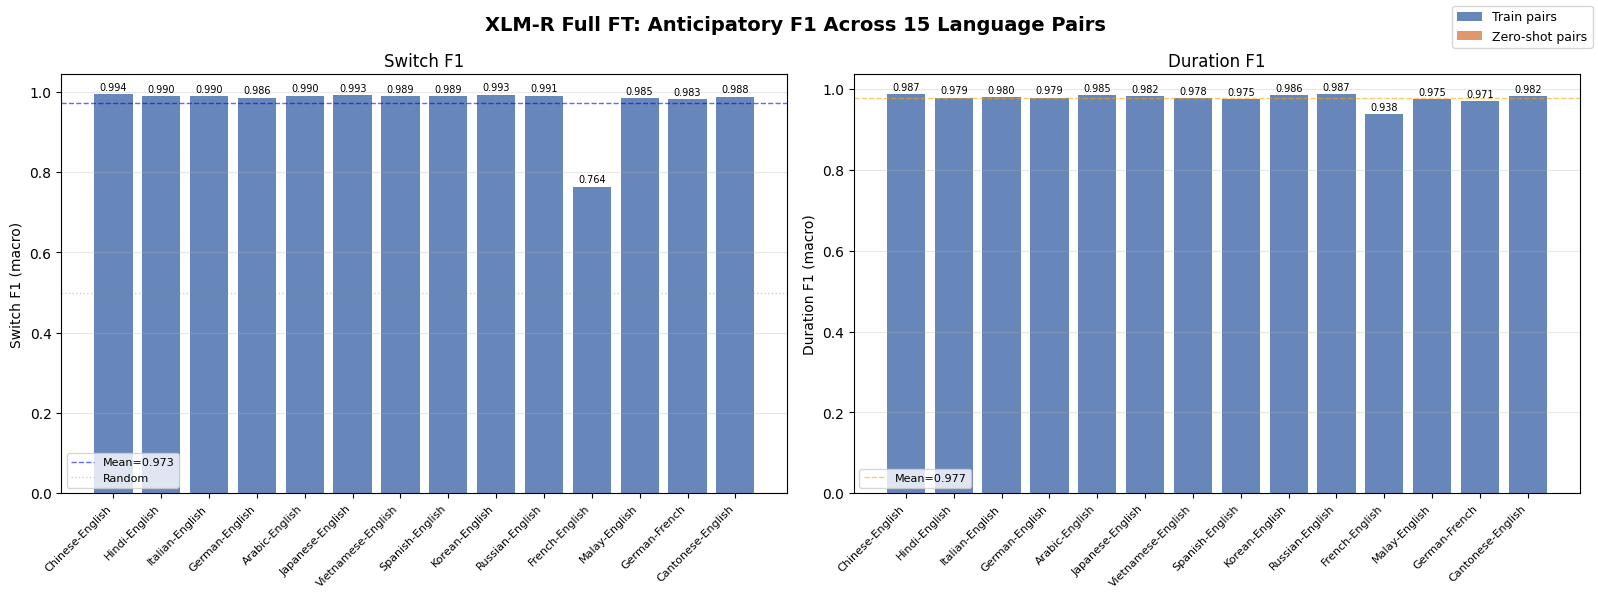


✓ XLM-R Final pipeline complete!
  σ_universality (Switch, all 15):   0.0581
  σ_universality (Duration, all 15): 0.0120


In [ ]:
# Cell 12: Visualization — Universality bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XLM-R Full FT: Anticipatory F1 Across 15 Language Pairs',
             fontsize=14, fontweight='bold')

# Prepare data in order: train pairs first, then zero-shot
pair_names = list(train_results.keys()) + list(zeroshot_results.keys())
sw_vals    = [all_results[p]['switch_f1'] for p in pair_names]
dur_vals   = [all_results[p]['duration_f1'] for p in pair_names]
colors     = ['#4C72B0'] * len(train_results) + ['#DD8452'] * len(zeroshot_results)

x = np.arange(len(pair_names))

# Switch F1
ax = axes[0]
bars = ax.bar(x, sw_vals, color=colors, alpha=0.85)
ax.axhline(np.mean(all_sw), color='blue', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Mean={np.mean(all_sw):.3f}')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, alpha=0.4, label='Random')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Switch F1 (macro)')
ax.set_title('Switch F1')
ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Duration F1
ax = axes[1]
bars = ax.bar(x, dur_vals, color=colors, alpha=0.85)
ax.axhline(np.mean(all_dur), color='orange', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Mean={np.mean(all_dur):.3f}')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('Duration F1 (macro)')
ax.set_title('Duration F1')
ax.set_xticks(x)
ax.set_xticklabels(pair_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', alpha=0.85, label='Train pairs'),
                   Patch(facecolor='#DD8452', alpha=0.85, label='Zero-shot pairs')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('xlmr_final_universality.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ XLM-R Final pipeline complete!")
print(f"  σ_universality (Switch, all 15):   {np.std(all_sw):.4f}")
print(f"  σ_universality (Duration, all 15): {np.std(all_dur):.4f}")